### **Ensemble Learning**

Ensemble learning is a method where multiple models are combined instead of using just one. Even if individual models are weak, combining their results gives more accurate and reliable predictions.

**Multiple Models:** Uses many small models together

**Better Accuracy:** Combined results improve performance

**Reduced Errors:** Mistakes of one model are balanced by those of others

**Simple Idea:** Like taking advice from a group instead of one person

1000 rows

splitting 1000 rows into 10 subsets each containing 100 rows

1 - DT - 12
2 - DT - 34
3 - DT -67
4 - DT - 23
5 - DT - 51
6 - DT - 21
7 - DT -14
8 - DT - 64
9 - DT - 29
10 - DT - 45

Mean - x

Final output - x

Bagging Technique- Random Forest



Boosting

Data -> Model -> error(200) -> Model -> error(100) ->Model -> error(50) ->Model ->error(20)

Best Algorithm Boosting -> Adaboost, Gradient Boosting, XGBoost, CatBoost

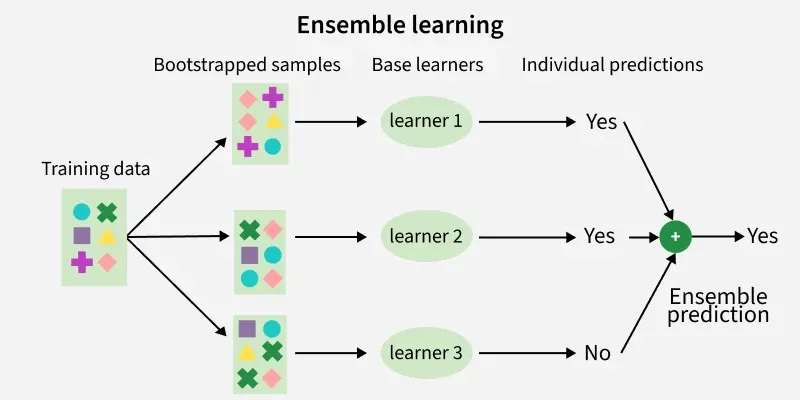

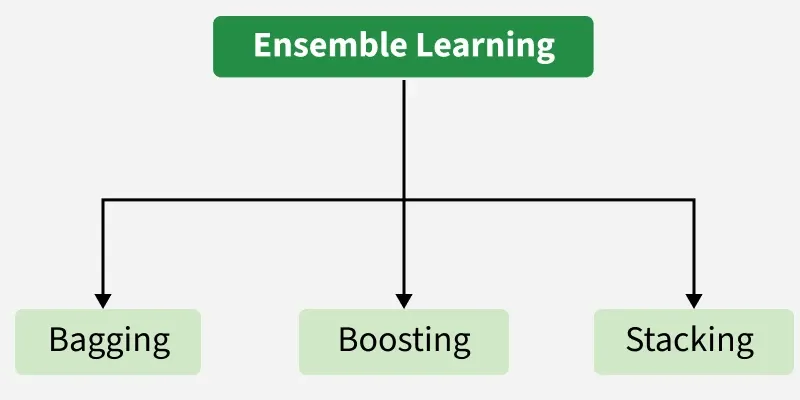

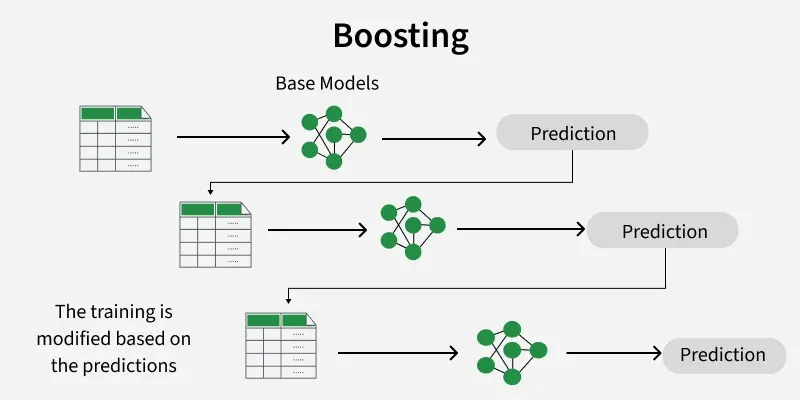

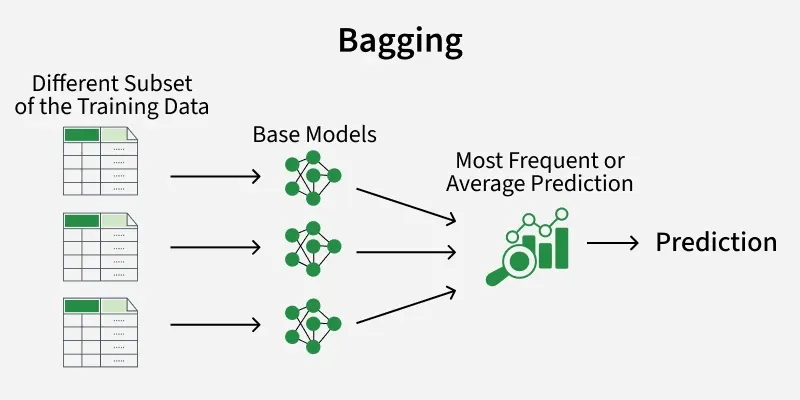

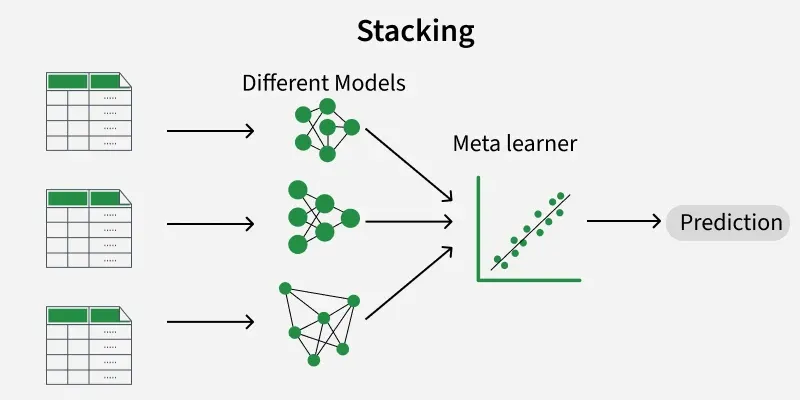

**Types of Ensemble Learning**

There are three main types of ensemble methods:

**Bagging (Bootstrap Aggregating):** Models are trained independently on different random subsets of the training data. Their results are then combined—usually by averaging (for regression) or voting (for classification). This helps reduce variance and prevents overfitting.

**Boosting:** Models are trained one after another. Each new model focuses on fixing the errors made by the previous ones. The final prediction is a weighted combination of all models, which helps reduce bias and improve accuracy.

**Stacking (Stacked Generalization):** Multiple different models (often of different types) are trained and their predictions are used as inputs to a final model, called a meta-model. The meta-model learns how to best combine the predictions of the base models, aiming for better performance than any individual model.

**1. Bagging Algorithm**

Bagging classifier can be used for both regression and classification tasks. Here is an overview of Bagging classifier algorithm:

**Bootstrap Sampling** : The dataset is divided into multiple subsets by sampling with replacement, creating diverse training data

**Base Model Training** : A separate model is trained on each subset independently, often in parallel for efficiency

**Prediction Aggregation** : Predictions from all models are combined using majority voting (classification) or averaging (regression)

**OOB Evaluation** : Samples not included in a subset are used to evaluate model performance without cross-validation

**Final Prediction** : The combined output of all models gives a more reliable and accurate result


**2. Boosting Algorithm**

Boosting is an ensemble technique where multiple weak models are trained one after another, and each new model focuses on correcting the errors of the previous one to build a strong model. The process works as follows:

**Initialize Weights** : Start with equal weights for all training data

**Train Weak Learner** : Train a simple model on the dataset

**Sequential Learning** : Each new model learns from previous errors

**Weight Adjustment** : Misclassified samples get higher weights so future models focus more on them

**Ensemble Learning Techniques**

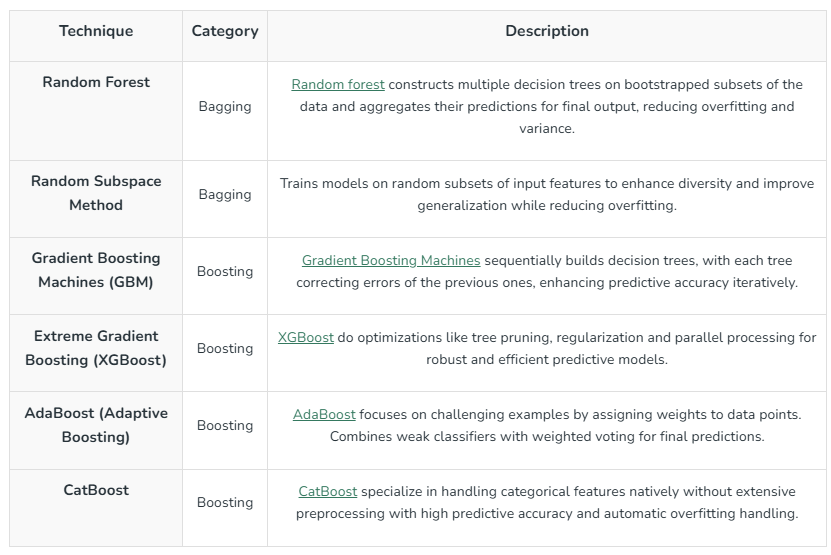

### **Random Forest**

Random Forest is a machine learning algorithm that uses many decision trees to make better predictions. Each tree looks at different random parts of the data and their results are combined by voting for classification or averaging for regression which makes it as ensemble learning technique. This helps in improving accuracy and reducing errors.

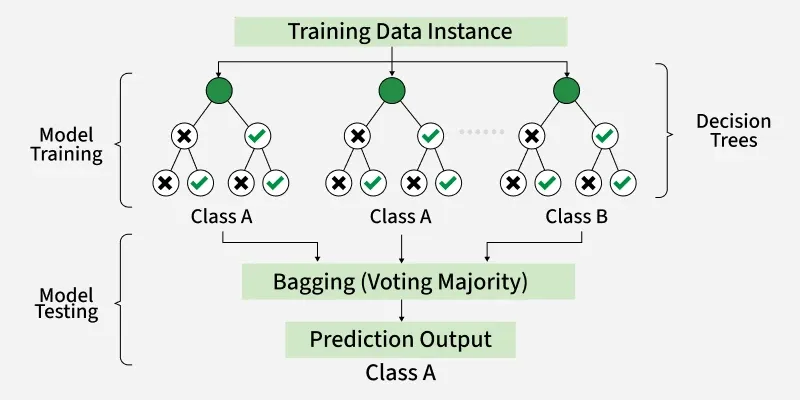

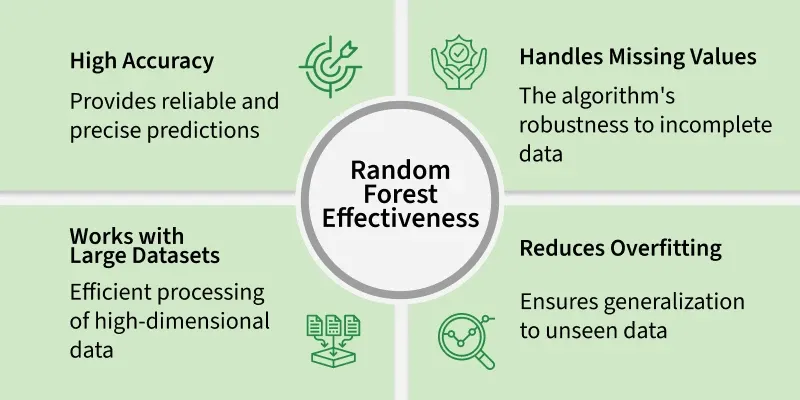

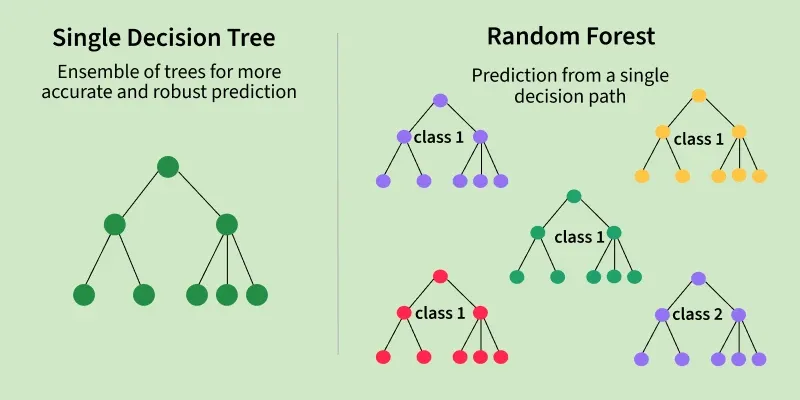

**Working of Random Forest Algorithm**

**Step 1** − First, start with the selection of random samples from a given dataset.

**Step 2** − Next, this algorithm will construct a decision tree for every sample. Then it will get the prediction result from every decision tree.

**Step 3** − In this step, voting will be performed for every predicted result.

**Step 4** − At last, select the most voted prediction result as the final prediction result.

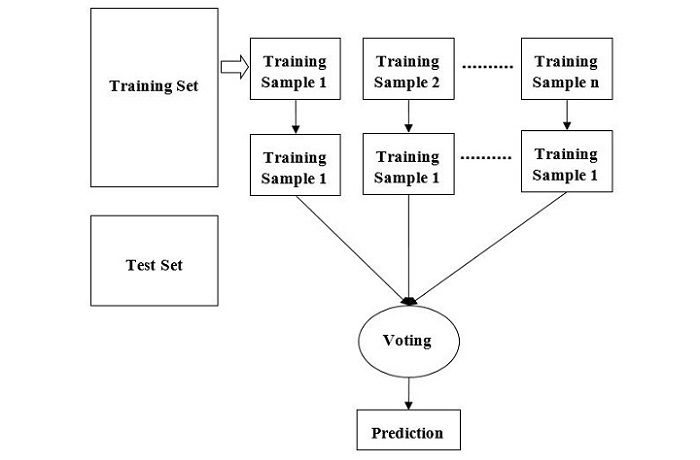

Parameters:

n_estimators -> Number of trees
max_depth -> Max depth of each node
max_features -> Number of features considered per split
min_sample_split -> Min samples to split a node

**Advantages of Random Forest Algorithm**

**Robustness to Overfitting** − Random Forest algorithm is known for its robustness to overfitting. This is because the algorithm uses an ensemble of decision trees, which helps to reduce the impact of outliers and noise in the data.

**High Accuracy** − Random Forest algorithm is known for its high accuracy. This is because the algorithm combines the predictions of multiple decision trees, which helps to reduce the impact of individual decision trees that may be biased or inaccurate.

**Handles Missing Data** − Random Forest algorithm can handle missing data without the need for imputation. This is because the algorithm only considers the features that are available for each data point and does not require all features to be present for all data points.

**Non-Linear Relationships** − Random Forest algorithm can handle non-linear relationships between the features and the target variable. This is because the algorithm uses decision trees, which can model non-linear relationships.

**Feature Importance** − Random Forest algorithm can provide information about the importance of each feature in the model. This information can be used to identify the most important features in the data and can be used for feature selection and feature engineering.

**Implementing Random Forest for Classification Tasks**

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

titanic_data = pd.read_csv('titanic.csv')

titanic_data = titanic_data.dropna(subset=['Survived'])

X = titanic_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = titanic_data['Survived']

X['Sex'] = X['Sex'].map({'female': 0, 'male': 1})
X['Age'] = X['Age'].fillna(X['Age'].median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

sample = X_test.iloc[0:1]
prediction = rf_classifier.predict(sample)

sample_dict = sample.iloc[0].to_dict()
print(f"\nSample Passenger: {sample_dict}")
print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did Not Survive'}")

Accuracy: 0.80

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


Sample Passenger: {'Pclass': 3.0, 'Sex': 1.0, 'Age': 28.0, 'SibSp': 1.0, 'Parch': 1.0, 'Fare': 15.2458}
Predicted Survival: Did Not Survive


**Implementing Random Forest for Regression Tasks**

In [4]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

california_housing = fetch_california_housing()
california_data = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
california_data['MEDV'] = california_housing.target

X = california_data.drop('MEDV', axis=1)
y = california_data['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

single_data = X_test.iloc[0].values.reshape(1, -1)
predicted_value = rf_regressor.predict(single_data)
print(f"Predicted Value: {predicted_value[0]:.2f}")
print(f"Actual Value: {y_test.iloc[0]:.2f}")

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Predicted Value: 0.51
Actual Value: 0.48
Mean Squared Error: 0.26
R-squared Score: 0.81


### **XGBoost**

Traditional models like decision trees and random forests are easy to interpret but may lack accuracy on complex data. XGBoost (eXtreme Gradient Boosting) is an optimized gradient boosting algorithm that combines multiple weak models into a stronger, high-performance model.

It uses decision trees as base learners, building them sequentially so each tree corrects errors from the previous one and it is known as boosting.
It features parallel processing for faster training on large datasets and allows parameter customization to optimize performance for specific problems.

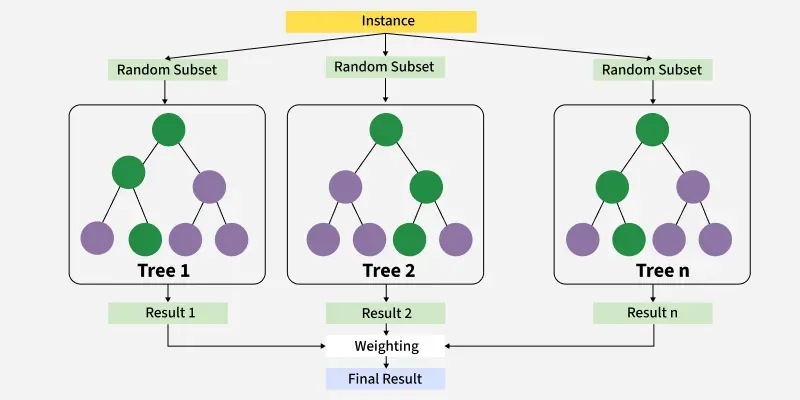

**How XGBoost Works?**

It builds decision trees sequentially with each tree attempting to correct the mistakes made by the previous one. The process can be broken down as follows:

**Start with a base learner:** The first model decision tree is trained on the data. In regression tasks this base model simply predicts the average of the target variable.

**Calculate the errors:** After training the first tree the errors between the predicted and actual values are calculated.

**Train the next tree:** The next tree is trained on the errors of the previous tree. This step attempts to correct the errors made by the first tree.

**Repeat the process**: This process continues with each new tree trying to correct the errors of the previous trees until a stopping criterion is met.

**Combine the predictions:** The final prediction is the sum of the predictions from all the trees.

**Implementation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

%matplotlib inline
sns.set_style("whitegrid")

df = pd.read_csv("Wholesale-customers-data.csv")

df.head()

print("\nStatistical Summary")
display(df.describe())




Statistical Summary


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [9]:
X = df.drop('Channel', axis=1)
y = df['Channel'].map({1:1, 2:0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [10]:
params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

model = XGBClassifier(**params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9090909090909091

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.92      0.85        38
           1       0.97      0.90      0.93        94

    accuracy                           0.91       132
   macro avg       0.88      0.91      0.89       132
weighted avg       0.92      0.91      0.91       132



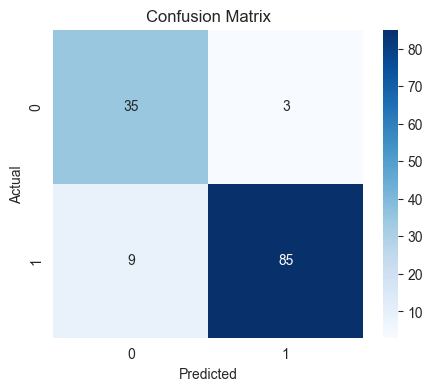

In [13]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 800x600 with 0 Axes>

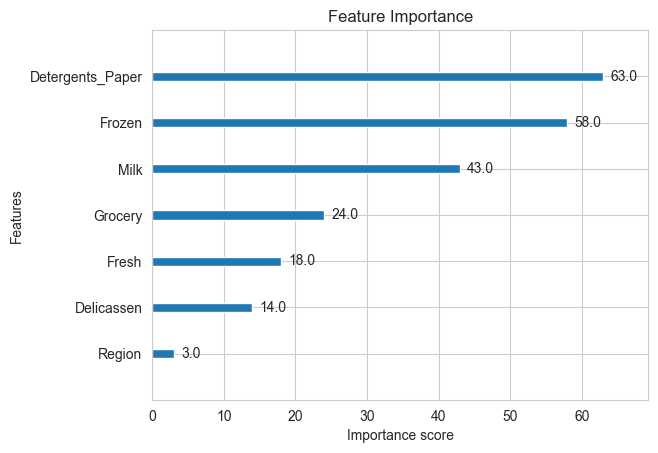

In [14]:
plt.figure(figsize=(8,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()